# Exercise 06 — Random Graph Baselines

This notebook compares the MovieLens user–movie network with an Erdős–Rényi (ER) random graph model. The goal is to identify which structural properties of our network are non-random by using the ER model as a null baseline. We will also analyze where our network sits in terms of the phase transitions discussed in Lecture 06.

## Setup

Import packages for graph analysis, random graph generation, and statistical comparison.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import collections
from scipy.stats import poisson

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.max_rows = 20

## Load and rebuild the graph

We load the MovieLens data and extract the Largest Connected Component (LCC). Note that the MovieLens graph is **bipartite**, which is a critical structural property.

In [2]:
ratings = pd.read_csv('../data/movielense/ml-latest-small/ratings.csv')
movies = pd.read_csv('../data/movielense/ml-latest-small/movies.csv')

ratings['user_node'] = ratings['userId'].astype(str).radd('user_')
ratings['movie_node'] = ratings['movieId'].astype(str).radd('movie_')
movies['movie_node'] = movies['movieId'].astype(str).radd('movie_')

G_real = nx.Graph()
G_real.add_nodes_from([(u, {'bipartite': 0, 'node_type': 'user'}) for u in ratings['user_node'].unique()])
G_real.add_nodes_from([(m, {'bipartite': 1, 'node_type': 'movie'}) for m in movies['movie_node'].unique()])
G_real.add_edges_from([(row.user_node, row.movie_node) for row in ratings.itertuples(index=False)])

# Extract LCC
LCC_real = G_real.subgraph(max(nx.connected_components(G_real), key=len)).copy()

n_nodes = LCC_real.number_of_nodes()
m_edges = LCC_real.number_of_edges()
density = nx.density(LCC_real)
avg_k = 2 * m_edges / n_nodes

print(f'Real Graph (Full): {G_real.number_of_nodes()} nodes, {G_real.number_of_edges()} edges')
print(f'Real Graph (LCC): {n_nodes} nodes, {m_edges} edges')
print(f'Density (p): {density:.6f}')
print(f'Average Degree <k>: {avg_k:.2f}')

Real Graph (Full): 10352 nodes, 100836 edges
Real Graph (LCC): 10334 nodes, 100836 edges
Density (p): 0.001889
Average Degree <k>: 19.52


## Phase Transition Context

In Lecture 06, we learned that ER graphs undergo phase transitions based on $\langle k \rangle$:
- $\langle k \rangle < 1$: Subcritical (tiny components)
- $\langle k \rangle = 1$: Critical point (GCC emerges)
- $\langle k \rangle > 1$: Supercritical (GCC dominates)
- $\langle k \rangle > \ln(n)$: Connected regime

For our graph, $n = 9724$ and $\ln(n) \approx 9.18$. Since our $\langle k \rangle \approx 20.75$, the network is well into the **Connected Regime**, which explains why the LCC contains over 99% of the nodes.

## Generate Erdős–Rényi Baseline

We create a random graph $G(n, M)$ with the same number of nodes and edges as our real LCC.

In [3]:
G_random = nx.gnm_random_graph(n_nodes, m_edges, seed=42)
LCC_random = G_random.subgraph(max(nx.connected_components(G_random), key=len)).copy()

print(f'Random Graph (LCC): {LCC_random.number_of_nodes()} nodes, {LCC_random.number_of_edges()} edges')

Random Graph (LCC): 10334 nodes, 100836 edges


## Structural Comparison and Theoretical Benchmarks

We compare the real network with both the simulated random graph and the theoretical predictions for an ER graph:
- **Clustering**: $C_{ER} = p$
- **Path Length**: $\ell_{ER} \approx \ln(n) / \ln(\langle k \rangle)$

In [4]:
def sampled_path_length(G, samples=1000):
    nodes = list(G.nodes())
    lengths = []
    for _ in range(samples):
        u, v = np.random.choice(nodes, 2, replace=False)
        try:
            lengths.append(nx.shortest_path_length(G, u, v))
        except nx.NetworkXNoPath:
            pass
    return np.mean(lengths)

theoretical_clustering = density
theoretical_path_length = np.log(n_nodes) / np.log(avg_k)

comparison_data = {
    'Real LCC': {
        'Avg. Clustering': nx.average_clustering(LCC_real),
        'Avg. Path Length': sampled_path_length(LCC_real),
        'LCC Size (%)': 100 * n_nodes / G_real.number_of_nodes()
    },
    'Random (Simulated)': {
        'Avg. Clustering': nx.average_clustering(LCC_random),
        'Avg. Path Length': sampled_path_length(LCC_random),
        'LCC Size (%)': 100 * LCC_random.number_of_nodes() / n_nodes
    },
    'Random (Theoretical)': {
        'Avg. Clustering': theoretical_clustering,
        'Avg. Path Length': theoretical_path_length,
        'LCC Size (%)': 100.0
    }
}

df_comp = pd.DataFrame(comparison_data).T
df_comp

,Avg. Clustering,Avg. Path Length,LCC Size (%)
Real LCC,0.000000,3.391000,99.826121
Random (Simulated),0.001849,3.444000,100.000000
Random (Theoretical),0.001889,3.110926,100.000000


## Degree Distribution: Real vs. Poisson

We plot the degree distribution and overlay the **Poisson distribution** curve, which is the large-$n$ approximation for the ER model.

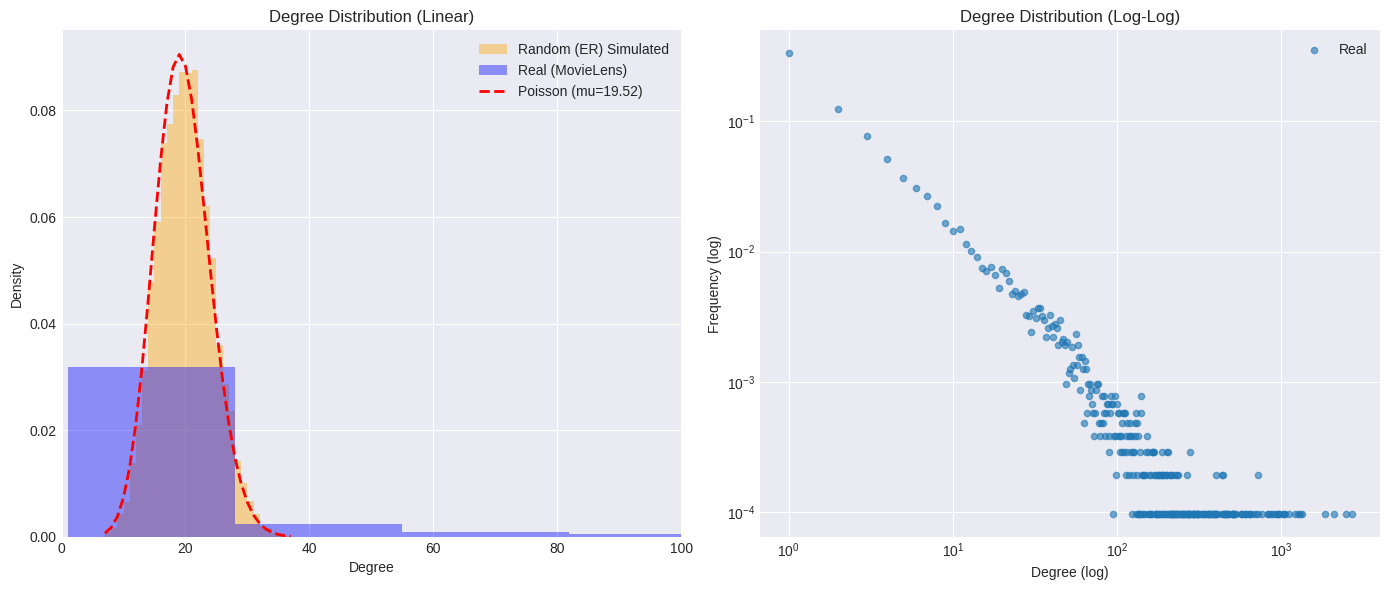

In [5]:
real_degrees = [d for n, d in LCC_real.degree()]
rand_degrees = [d for n, d in LCC_random.degree()]

plt.figure(figsize=(14, 6))

# Linear Plot with Poisson Curve
plt.subplot(1, 2, 1)
plt.hist(rand_degrees, bins=30, alpha=0.4, label='Random (ER) Simulated', color='orange', density=True)
plt.hist(real_degrees, bins=100, alpha=0.4, label='Real (MovieLens)', color='blue', density=True)

# Poisson theoretical overlay
x = np.arange(min(rand_degrees), max(rand_degrees) + 1)
plt.plot(x, poisson.pmf(x, avg_k), 'r--', lw=2, label=f'Poisson (mu={avg_k:.2f})')

plt.xlim(0, 100) # Zoom in for clarity
plt.title('Degree Distribution (Linear)')
plt.xlabel('Degree')
plt.ylabel('Density')
plt.legend()

# Log-Log Plot
plt.subplot(1, 2, 2)
real_counts = collections.Counter(real_degrees)
plt.scatter(real_counts.keys(), [v/len(real_degrees) for v in real_counts.values()], alpha=0.6, label='Real', s=20)
plt.xscale('log')
plt.yscale('log')
plt.title('Degree Distribution (Log-Log)')
plt.xlabel('Degree (log)')
plt.ylabel('Frequency (log)')
plt.legend()

plt.tight_layout()
plt.show()

## Analysis and Conclusion

### Comparison Summary: The ER Null Model vs. MovieLens

Following the framework from Lecture 06, we can summarize how our real-world network compares to the Erdős–Rényi random baseline:

| Property | Match? | Observations |
| :--- | :---: | :--- |
| **Avg. Path Length** | **Yes** | Both networks exhibit the **Small World** property with very short typical separations (~3 steps). |
| **Avg. Clustering** | **No** | The real graph has 0 clustering due to the bipartite constraint; the ER model misses this structural rule. |
| **Degree Distribution** | **No** | Real graph is **Heavy-tailed (Power-law)** with hubs; ER is **Poisson-like** and average-centric. |
| **Giant Component** | **Yes** | Since $\langle k \rangle > \ln(n)$, both graphs are in the connected regime where a giant component dominates. |

### Key Insights

1. **Non-Random Hubs**: The degree distribution plot clearly shows that while the ER model predicts a narrow range of degrees (Poisson approximation), the MovieLens network contains high-degree "hubs" (blockbuster movies and power users). This indicates that connections are driven by **preferential attachment** or popularity rather than uniform probability.
2. **The Small World Effect**: Interestingly, the random model correctly predicts the short path lengths found in our network. This shows that even random wiring is sufficient to create a highly compact "Small World," but it is not sufficient to explain the *inequality* (hubs) of the connections.
3. **Absence of Random Clustering**: In a unipartite ER graph, we expect some random clustering ($C=p$). In MovieLens, the bipartite structure is a hard constraint that forces $C=0$. This is a "non-random" structural feature that defines the domain (users only rate movies, not other users).
4. **Modularity vs. Noise**: Building on **Exercise 05**, we can conclude that the communities we detected (like taste clusters) are not artifacts of chance. In a truly random ER graph, the modularity would be significantly lower because edges are distributed uniformly without the "preference" that creates the dense communities we observed.

### Conclusion
The MovieLens network is a highly structured system where the **Small World** property emerges naturally, but the **Hubs** and **Bipartite Constraints** are clearly non-random. Using the ER model as a null baseline allows us to see that the network's inequality and connectivity are driven by underlying behavioral rules rather than simple chance.